In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

plt.rcParams["svg.fonttype"] = "none"

In [2]:
fig_dir = Path('figures/figure1')
fig_dir.mkdir(exist_ok=True, parents=True)

# Storage stats

In [3]:
df_hlca = pd.read_table('data/output/HLCAv1/QC_storage.tsv')
df_hlca.columns = df_hlca.columns.str.strip()
df_hlca["folder"] = df_hlca["folder"].str.strip().str.removeprefix("data/pipeline/HLCAv1/QC/")
df_hlca

,folder,actual_bytes,expanded_bytes,ratio
0,clustering,8189005929,1069048905702,130.54
1,collect,4562563526,43854777814,9.61
2,doublets,961815366,613533880011,637.89
3,filter,242577853,70071324170,288.86
4,integration,2280333177,251850503687,110.44
5,label_transfer,894773740,118170002247,132.06
6,majority_voting,476517260,43458270177,91.19
7,marker_genes,5238867521,465728091876,88.89
8,merge,29223101640,29223101640,1.00
9,metrics,8750660137,618428356112,70.67


In [4]:
df_hrca = pd.read_table('data/output/HRCA_storage.tsv')
df_hrca.columns = df_hrca.columns.str.strip()
df_hrca["folder"] = df_hrca["folder"].str.removeprefix("data/pipeline/HRCA//")
df_hrca

,folder,actual_bytes,expanded_bytes,ratio
0,clustering,62875835496,58689470021856,9.334100e+02
1,collect,385559642,286021984451,7.418300e+02
2,doublets,371501635,38692025532,1.041500e+02
3,integration,217199998395,19740868877172,9.088000e+01
4,label_transfer,7993125520,10057120508231,1.258220e+03
5,majority_voting,388420394,286024845995,7.363700e+02
6,merge,257,38585983958,1.501400e+08
7,metrics,108646213895,43849587286781,4.035900e+02
8,preprocessing,50678805195,2980403594154,5.880000e+01
9,qc,529703482,77170744172,1.456800e+02


## Figure 1 plots

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

In [6]:
SAVE = fig_dir
FIG_KW = dict(facecolor="white", dpi=300)

COLORS = {
    "hlca": {"actual": "#2166ac", "expanded": "#2166ac44"},
    "hrca": {"actual": "#d6604d", "expanded": "#d6604d44"},
}
RATIO_COL = "#4d4d4d"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": "#dddddd", "grid.linewidth": 0.5,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
    "legend.fontsize": 6.5, "legend.frameon": False,
})

In [7]:
from matplotlib.patches import Patch


def to_gib(b):
    gb = b / 1024**3
    return gb if gb > 0.1 else 0

def style_axis(ax, ylabel, title=None, log=True):

    if log:
        ax.set_yscale("symlog", linthresh=1)
        ax.yaxis.set_major_locator(ticker.SymmetricalLogLocator(base=10, linthresh=1))
        ax.yaxis.set_minor_locator(
            ticker.SymmetricalLogLocator(base=10, linthresh=1, subs=[2, 3, 4, 5, 6, 7, 8, 9])
        )
        ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=4)
    ax.grid(axis="y", linestyle=":", linewidth=0.5)

def _outside_legend(ax, handles, labels, y=1.0, **kw):
    """Frameless legend anchored to the right of the axes at height y."""
    return ax.legend(
        handles,
        labels,
        loc="upper left",
        bbox_to_anchor=(1.02, y),
        frameon=False,
        borderaxespad=0,
        **kw
    )

def legend_outside(ax, palette, labels, **kw):
    handles = [Patch(facecolor=palette["expanded"]), Patch(facecolor=palette["actual"])]
    _outside_legend(ax, handles, labels, **kw)


def legend_totals(ax, datasets):
    # Shade legend: light = expanded, dark = actual (hue-neutral grays)
    shade = _outside_legend(
        ax,
        [Patch(facecolor="#c9c9c9"), Patch(facecolor="#4d4d4d")],
        ["Expanded", "Actual"], y=1.0, fontsize=6,
    )
    ax.add_artist(shade)  # keep it when the second legend replaces the default

    # Color legend: one entry per dataset, using its representative hue
    _outside_legend(
        ax,
        [Patch(facecolor=palette["actual"]) for _, _, palette in datasets],
        [label for label, _, _ in datasets], y=0.55, fontsize=6,
    )


def draw_nested_bars(ax, x, actual, expanded, actual_color, expanded_color, inner_width=0.38):
    """Draw wide 'expanded' bars with narrower 'actual' bars nested inside."""
    ax.bar(x, expanded, width=inner_width * 2, color=expanded_color, linewidth=0, zorder=2)
    ax.bar(x, actual,   width=inner_width,     color=actual_color,   linewidth=0, zorder=3)


def save(fig, stem):
    fig.tight_layout()
    if stem:
        fig.savefig(f"{SAVE}/{stem}.svg", bbox_inches="tight")


def plot_pipeline_storage(df, palette, title, figsize, stem=None, log=True):
    fig, ax = plt.subplots(figsize=figsize, **FIG_KW)
    x = np.arange(len(df))
    draw_nested_bars(
        ax, x,
        actual=df["actual_bytes"].apply(to_gib),
        expanded=df["expanded_bytes"].apply(to_gib),
        actual_color=palette["actual"],
        expanded_color=palette["expanded"],
    )
    ax.set_xticks(x)
    ax.set_xticklabels(df["folder"], rotation=90, ha="right", rotation_mode="anchor")
    ax.set_ylim(bottom=0)
    style_axis(ax, "Storage (GiB)", title, log=log)
    legend_outside(ax, palette, ["Expanded", "Actual"])
    save(fig, stem)


def plot_totals(datasets, figsize, stem=None, log=True):
    """datasets: list of (label, df, palette)."""
    totals = pd.DataFrame([
        {"label": label,
         "actual":   df["actual_bytes"].sum(),
         "expanded": df["expanded_bytes"].sum(),
         "ratio":    df["expanded_bytes"].sum() / df["actual_bytes"].sum(),
         "palette":  palette}
        for label, df, palette in datasets
    ])

    fig, ax = plt.subplots(figsize=figsize, **FIG_KW)
    x = np.arange(len(totals))
    actual   = totals["actual"].apply(to_gib)
    expanded = totals["expanded"].apply(to_gib)
    draw_nested_bars(
        ax, x,
        actual=actual, expanded=expanded,
        actual_color=[p["actual"]   for p in totals["palette"]],
        expanded_color=[p["expanded"] for p in totals["palette"]],
        inner_width=0.3,
    )
    for xi, eg, ratio in zip(x, expanded, totals["ratio"]):
        ax.text(xi, eg * 1.08, f"×{ratio:.1f}",
                ha="center", fontsize=6.5, color=RATIO_COL, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(totals["label"])
    style_axis(ax, "Storage (GiB)", log=log)
    legend_totals(ax, datasets)
    save(fig, stem)

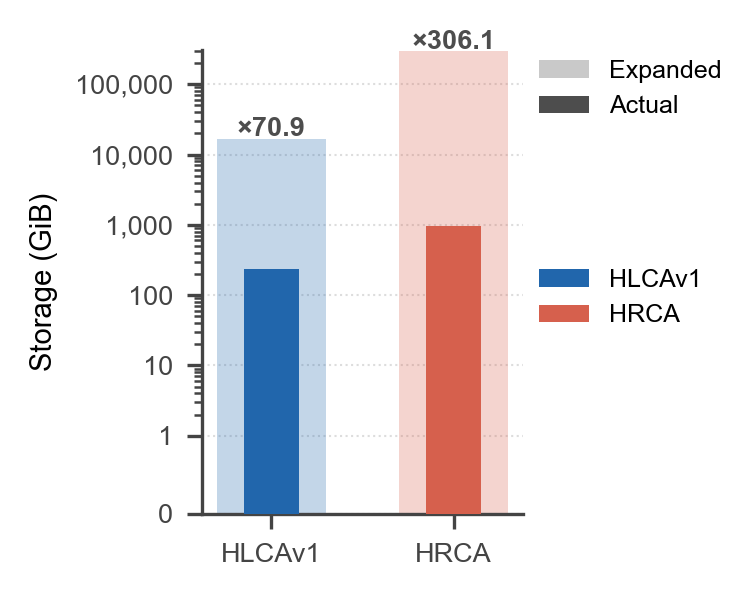

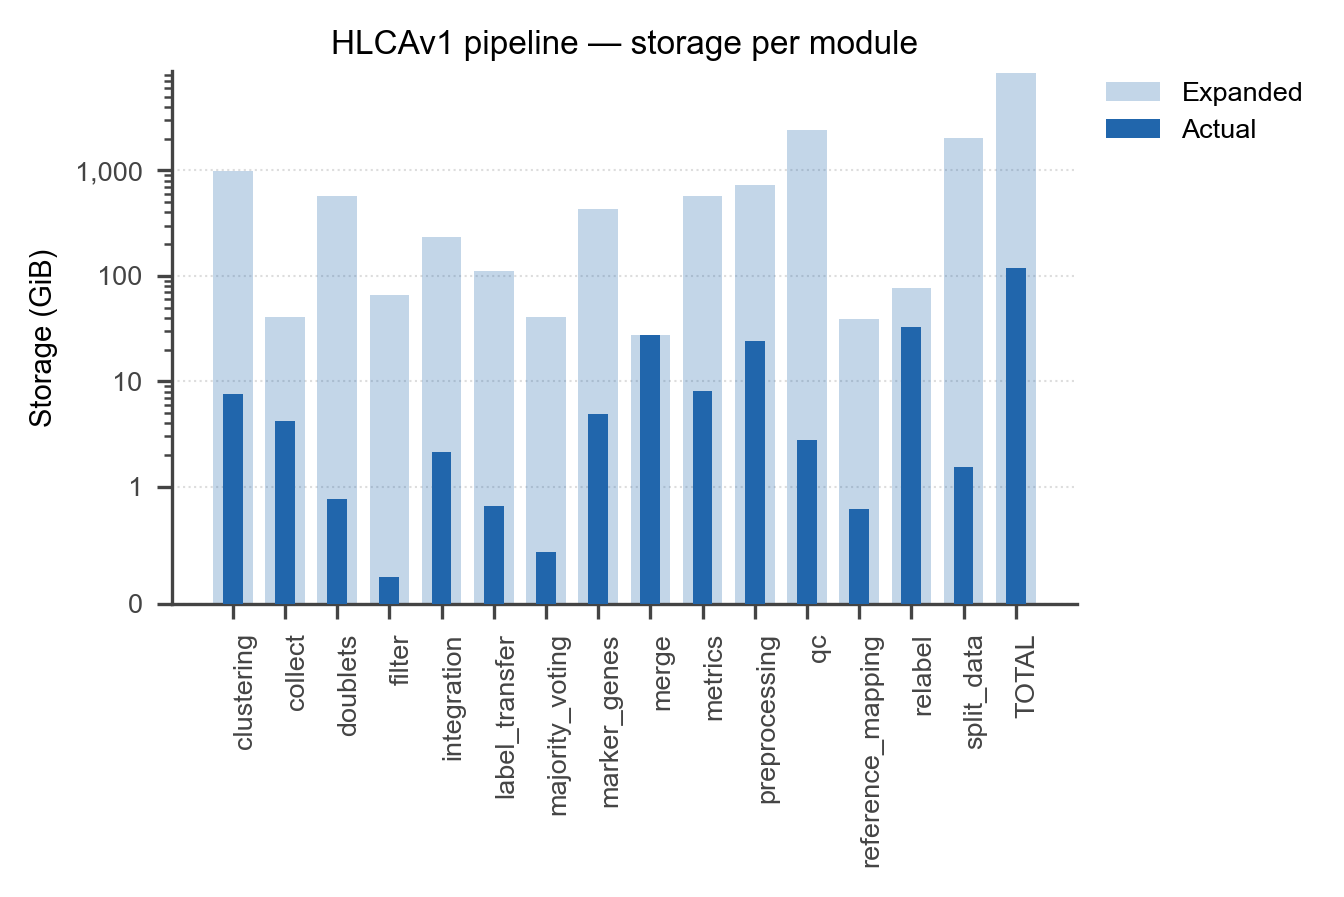

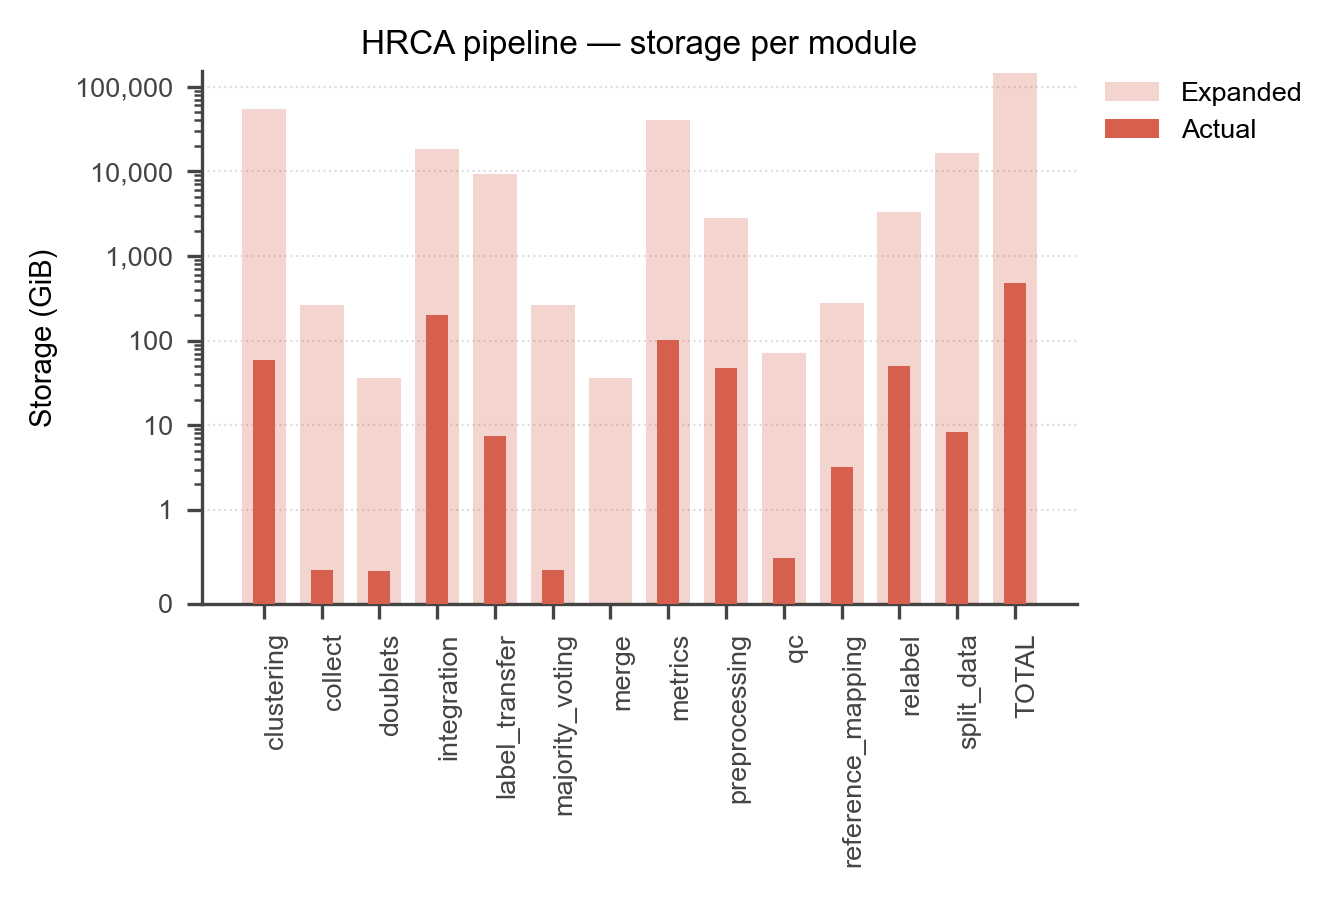

In [8]:
plot_totals([("HLCAv1", df_hlca, COLORS["hlca"]), ("HRCA", df_hrca, COLORS["hrca"])], (2.5, 2), "F")
plot_pipeline_storage(df_hlca, COLORS["hlca"], "HLCAv1 pipeline — storage per module", (4.5, 3.0), "supp_A")
plot_pipeline_storage(df_hrca, COLORS["hrca"], "HRCA pipeline — storage per module",   (4.5, 3.0), "supp_B")

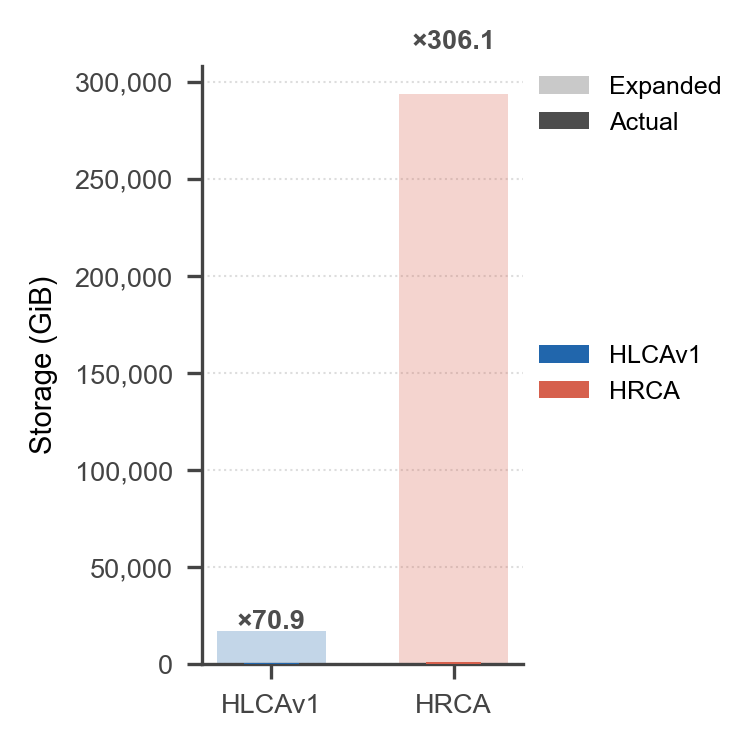

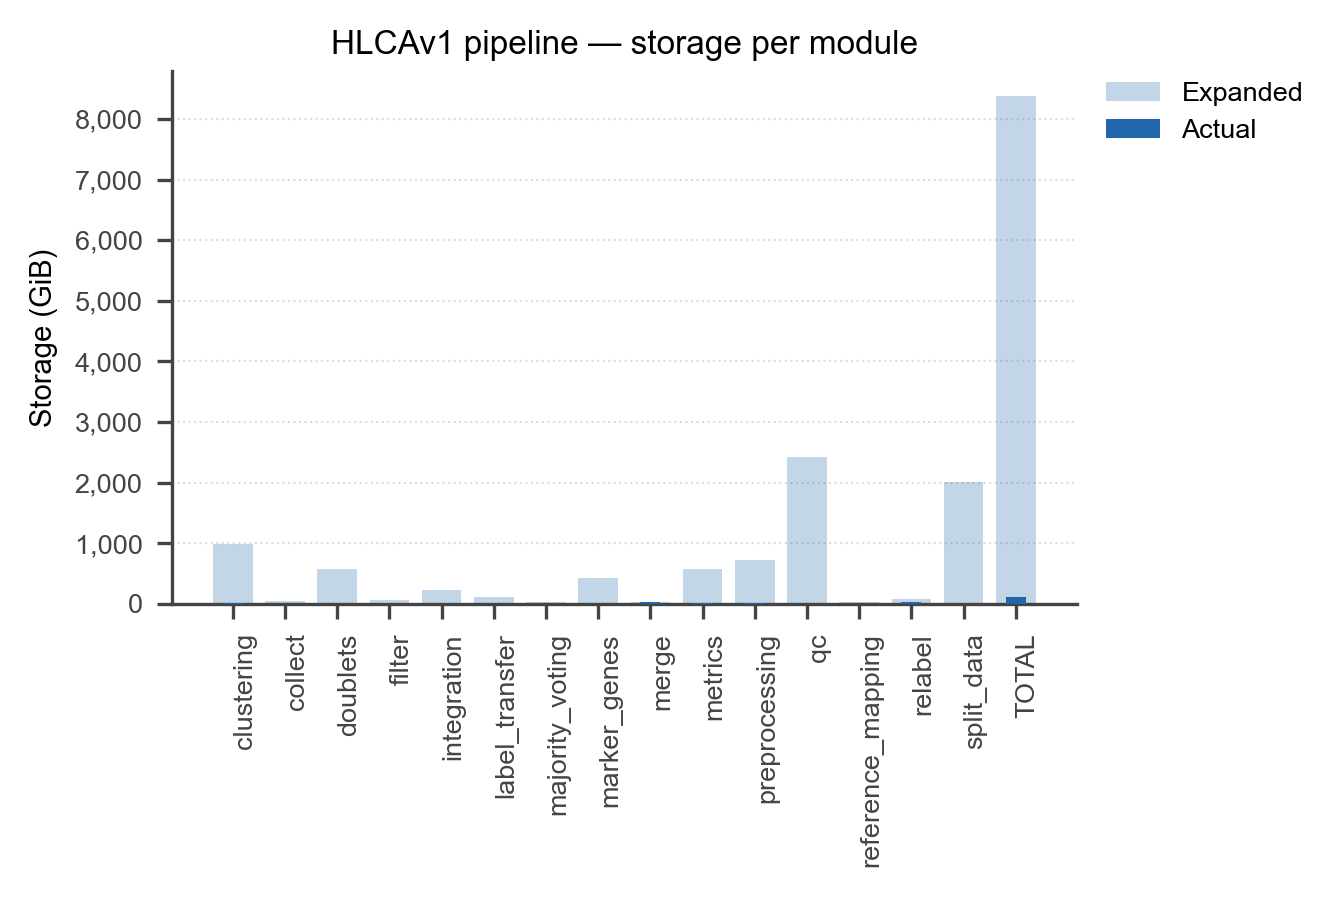

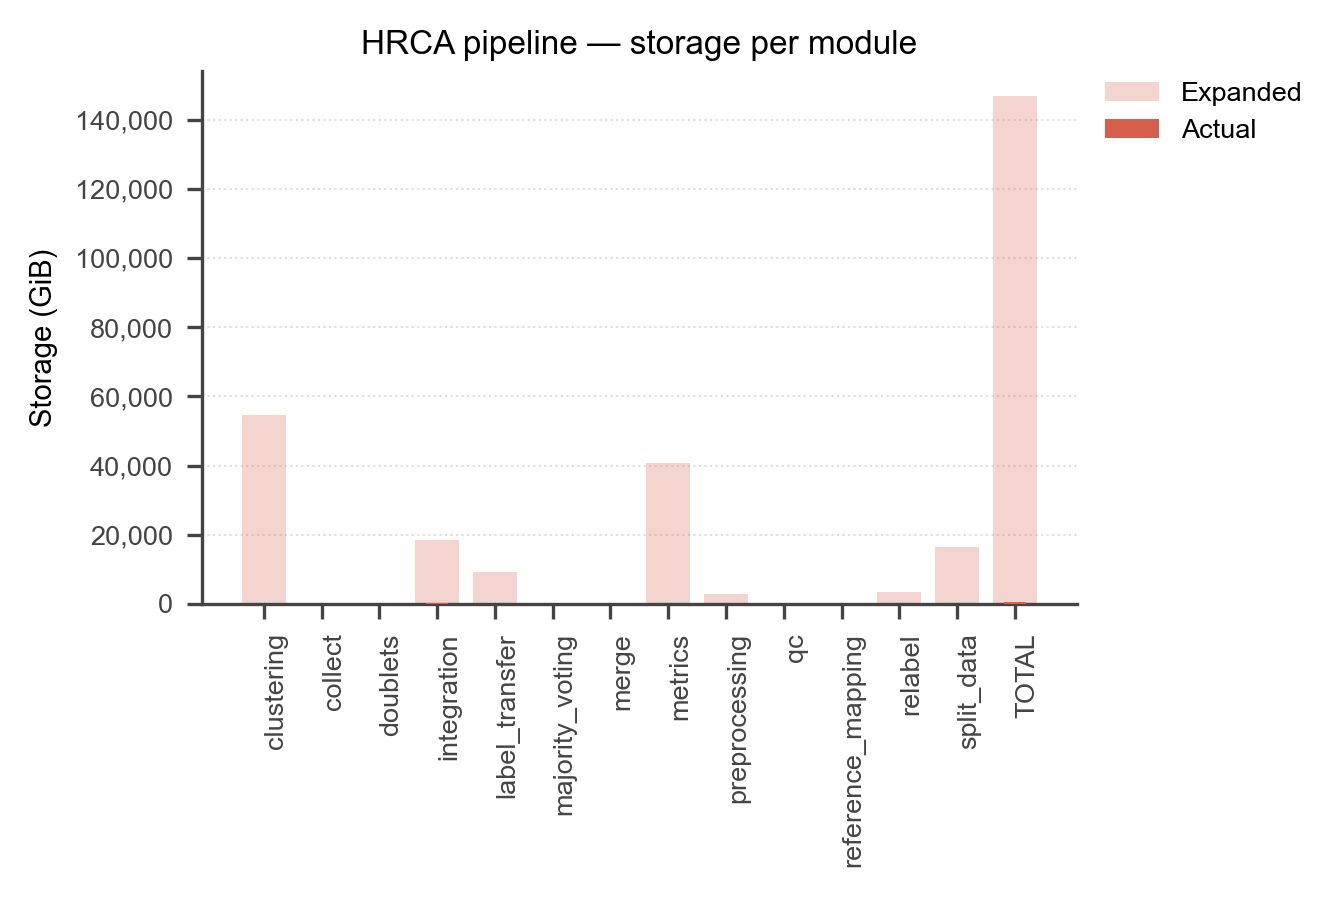

In [9]:
plot_totals([("HLCAv1", df_hlca, COLORS["hlca"]), ("HRCA", df_hrca, COLORS["hrca"])], (2.5, 2.5), log=False)
plot_pipeline_storage(df_hlca, COLORS["hlca"], "HLCAv1 pipeline — storage per module", (4.5, 3.0), log=False)
plot_pipeline_storage(df_hrca, COLORS["hrca"], "HRCA pipeline — storage per module",   (4.5, 3.0), log=False)